In [1]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
import datetime
from scipy.constants import mu_0

In [2]:
cop24 = np.load('cop24.npz')
exp_raw = cop24['ex_raw']
eyp_raw = cop24['ey_raw']
hxp_raw = cop24['hx_raw']
hyp_raw = cop24['hy_raw']

In [226]:
decl = 0#8.28165279057217
cop24_az = {
    'ex': (334.3 + decl) * np.pi/180, #degrees
    'ey': (64.3 + decl) * np.pi/180,
    'hx': (8.3 + decl) * np.pi/180,
    'hy' : (98.3 + decl) * np.pi/180,
}

coo24_az = {
    'ex': (337.4 + decl) * np.pi/180, #degrees
    'ey': (67.4 + decl) * np.pi/180,
    'hx': (8.4 + decl) * np.pi/180,
    'hy' : (98.4 + decl) * np.pi/180,
}

In [227]:
e_hp = np.c_[exp_raw, eyp_raw]
h_hp = np.c_[hxp_raw, hyp_raw]

In [228]:
th = np.pi/2 - cop24_az['ex']
u_ex = np.r_[np.cos(th), np.sin(th)]

th = np.pi/2 - cop24_az['ey']
u_ey = np.r_[np.cos(th), np.sin(th)]

U_e = np.c_[u_ex, u_ey]

th = np.pi/2 - cop24_az['hx']
u_hx = np.r_[np.cos(th), np.sin(th)]

th = np.pi/2 - cop24_az['hy']
u_hy = np.r_[np.cos(th), np.sin(th)]

U_h = np.c_[u_hx, u_hy]

In [263]:
e_r = np.linalg.solve(U_e, e_hp[..., None])[..., 0]
h_r = np.linalg.solve(U_h, h_hp[..., None])[..., 0]

# e_r = (U_e @ e_hp[..., None])[..., 0]
# h_r = (U_h @ h_hp[..., None])[..., 0]

print(h_r.shape)

ex_raw, ey_raw = e_r.T
hx_raw, hy_raw = h_r.T

(1523584, 2)


In [264]:
dipole_length = 100
e_gain = 409600000.0

start = datetime.datetime.fromisoformat("2018-09-13T15:14:30+00:00")
end = datetime.datetime.fromisoformat("2018-10-01T06:27:33+00:00")
sample_rate = 1 #Hz

time_delay = {
    "ex":datetime.timedelta(seconds=-0.285),
    "ey":datetime.timedelta(seconds=-0.285),
    "hx":datetime.timedelta(seconds=-0.192),
    "hy":datetime.timedelta(seconds=-0.201),
    "hz":datetime.timedelta(seconds=-0.21),
}

nims_low_pass_e = {
    'p':[-3.883009+11.951875j,-3.883009-11.951875j,-10.166194 +7.386513j,-10.166194 -7.386513j,-12.566371 +0.j],
    'z': [],
    'k':313383.493219835
}

nims_high_pass_e = {
    'p':[-0.000167, ],
    'z':[0.0],
    'k':1.00000000378188,
}


h_gain = 100
nims_low_pass_h = {
    'p':[-6.283185+10.882477j, -6.283185-10.882477j,-12.566371+0.j],
    'z':[],
    'k':2002.26936395594 * 1E9 * mu_0 # 1E-9 / mu_0 # V/nT -> , # last bit is nT -> A/m
}

In [265]:
n_samples = len(ex_raw)
n_divisions = 100

In [324]:
n_leftovers = n_samples % n_divisions
ex_slices = ex_raw[:-n_leftovers].reshape(n_divisions, -1)
ey_slices = ey_raw[:-n_leftovers].reshape(n_divisions, -1)
hx_slices = hx_raw[:-n_leftovers].reshape(n_divisions, -1)
hy_slices = hy_raw[:-n_leftovers].reshape(n_divisions, -1)

n_window = ex_slices.shape[-1] 

In [325]:
it = np.arange(n_window)
ex_l_trend = np.polyfit(it, ex_slices.T, 1)
ey_l_trend = np.polyfit(it, ey_slices.T, 1)
hx_l_trend = np.polyfit(it, hx_slices.T, 1)
hy_l_trend = np.polyfit(it, hy_slices.T, 1)

In [326]:
ex_slices_dt = ex_slices - ex_l_trend[0][:, None]*it - ex_l_trend[1][:, None]
ey_slices_dt = ey_slices - ey_l_trend[0][:, None]*it - ey_l_trend[1][:, None]
hx_slices_dt = hx_slices - hx_l_trend[0][:, None]*it - hx_l_trend[1][:, None]
hy_slices_dt = hy_slices - hy_l_trend[0][:, None]*it - hy_l_trend[1][:, None]

In [329]:
window = sig.windows.hamming(n_window)

In [330]:
Ex = np.fft.rfft(ex_slices_dt * window)[...,1:]  # the [1:] portion cuts off the zero frequency
Ey = np.fft.rfft(ey_slices_dt * window)[...,1:]

Hx = np.fft.rfft(hx_slices_dt * window)[...,1:]
Hy = np.fft.rfft(hy_slices_dt * window)[...,1:]

f = np.fft.rfftfreq(ex_slices.shape[-1], 1)[1:]

In [331]:
omega = 2 * np.pi * f
_, e_lowpass = sig.freqs_zpk(**nims_low_pass_e, worN=omega)
_, e_highpass = sig.freqs_zpk(**nims_high_pass_e, worN=omega)

_, h_lowpass = sig.freqs_zpk(**nims_low_pass_h, worN=omega)

In [332]:
Ex_cal = Ex / (e_gain * dipole_length * e_lowpass * e_highpass)
Ey_cal = Ey / (e_gain * dipole_length * e_lowpass * e_highpass)

Hx_cal = Hx / (h_gain * h_lowpass)
Hy_cal = Hy / (h_gain * h_lowpass)

In [507]:
period_bands = np.r_[
    np.logspace(np.log10(5), np.log10(1000), 25),
    np.logspace(np.log10(1000), np.log10(20000), 7)[1:]
]
n_bands = len(period_bands) - 1

freq_bands = 1.0/period_bands[::-1]
freq_bands

array([5.00000000e-05, 8.23774486e-05, 1.35720881e-04, 2.23606798e-04,
       3.68403150e-04, 6.06962231e-04, 1.00000000e-03, 1.24702813e-03,
       1.55507915e-03, 1.93922745e-03, 2.41827118e-03, 3.01565218e-03,
       3.76060309e-03, 4.68957784e-03, 5.84803548e-03, 7.29266474e-03,
       9.09415806e-03, 1.13406709e-02, 1.41421356e-02, 1.76356409e-02,
       2.19921403e-02, 2.74248176e-02, 3.41995189e-02, 4.26477621e-02,
       5.31829590e-02, 6.63206458e-02, 8.27037108e-02, 1.03133854e-01,
       1.28610817e-01, 1.60381306e-01, 2.00000000e-01])

In [508]:
bands = (f[:,None] >= freq_bands[:-1]) & (f[:, None] < freq_bands[1:])

In [518]:
f_per_band = np.sum(bands, axis=0)

f2 = np.broadcast_to(f[:, None], (f.shape[0], 30))
f_band = np.add.reduce(f2, axis=-2, where=bands)/f_per_band

band = Ex_cal
band = np.broadcast_to(band[..., None], (*band.shape, 30))
Ex_band = np.add.reduce(band, axis=-2, where=bands)/f_per_band

band = Ey_cal
band = np.broadcast_to(band[..., None], (*band.shape, 30))
Ey_band = np.add.reduce(band, axis=-2, where=bands)/f_per_band

band = Hx_cal
band = np.broadcast_to(band[..., None], (*band.shape, 30))
Hx_band = np.add.reduce(band, axis=-2, where=bands)/f_per_band

band = Hy_cal
band = np.broadcast_to(band[..., None], (*band.shape, 30))
Hy_band = np.add.reduce(band, axis=-2, where=bands)/f_per_band

In [540]:
def band_sum(band, where=bands):
    band = np.broadcast_to(band[..., None], (*band.shape, where.shape[-1]))
    return np.add.reduce(band, axis=-2, where=bands)

In [541]:
Ex_band.shape

(100, 30)

In [544]:
def Z_func(Ex, Ey, Hx, Hy, Rx=None, Ry=None, bands=None):
    if Rx is None:
        Rx = Hx
    if Ry is None:
        Ry = Hy
    Rxc = Rx.conjugate()
    Ryc = Ry.conjugate()

    if bands is not None:
        func = lambda x : np.sum(band_sum(x, where=bands), axis=0)
    else:
        func = lambda x : np.sum(x, axis=0)

    bot = func(Hx * Rxc) * func(Hy * Ryc) - func(Hx * Ryc) * func(Hy * Rxc)

    top_xx = func(Ex * Rxc) * func(Hy * Ryc) - func(Ex * Ryc) * func(Hy * Rxc)
    top_xy = func(Ex * Ryc) * func(Hx * Rxc) - func(Ex * Rxc) * func(Hx * Ryc)

    top_yx = func(Ey * Rxc) * func(Hy * Ryc) - func(Ey * Ryc) * func(Hy * Rxc)
    top_yy = func(Ey * Ryc) * func(Hx * Rxc) - func(Ey * Rxc) * func(Hx * Ryc)

    zx = np.stack([top_xx, top_xy], axis=-1)
    zy = np.stack([top_yx, top_yy], axis=-1)

    Z = np.stack([zx, zy], axis=1) / bot[:, None, None]
    
    return Z

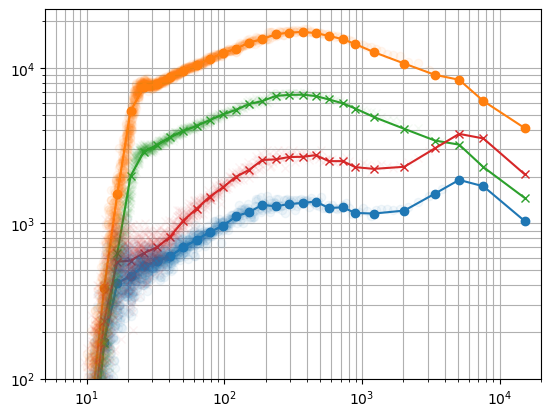

In [545]:
Z = Z_func(Ex_cal, Ey_cal, Hx_cal, Hy_cal, bands=bands)
T = 1/f_band
om = 2 * np.pi/T
rho_a = 1/(mu_0 * om[:, None, None]) * np.abs(Z)**2

plt.loglog(T, rho_a[:, 1, 0], 'C0', marker='o')
plt.loglog(T, rho_a[:, 0, 1], 'C1', marker='o')
plt.loglog(T, rho_a[:, 1, 1], 'C2', marker='x')
plt.loglog(T, rho_a[:, 0, 0], 'C3', marker='x')

Z = Z_func(Ex_cal, Ey_cal, Hx_cal, Hy_cal)
T = 1/f
om = 2 * np.pi/T
rho_a = 1/(mu_0 * om[:, None, None]) * np.abs(Z)**2

plt.loglog(T, rho_a[:, 1, 0], 'C0', marker='o', linestyle="", alpha=0.05)
plt.loglog(T, rho_a[:, 0, 1], 'C1', marker='o', linestyle="", alpha=0.05)
plt.loglog(T, rho_a[:, 1, 1], 'C2', marker='x', linestyle="", alpha=0.05)
plt.loglog(T, rho_a[:, 0, 0], 'C3', marker='x', linestyle="", alpha=0.05)

plt.ylim([1E2, 24_000])
plt.xlim([5, 20_000])
plt.grid(which='both')